Project Overview

This project focuses on predicting whether a person has diabetes based on diagnostic measurements such as glucose level, blood pressure, BMI, insulin level, and age.

The project follows a complete machine learning workflow:

Loading a dataset programmatically from Kaggle
Understanding the dataset
Performing Preliminary Data Analysis (PDA)
Checking missing and invalid values
Visualizing important patterns
Preparing the data for machine learning
Splitting the data into training and testing sets
Training a Logistic Regression classification model
Evaluating the model using accuracy, confusion matrix, precision, recall, F1-score, MAE, MSE, RMSE, and R²
Checking for overfitting by comparing training and testing performance
Comparing model predictions with actual outcomes

The target variable is Outcome:

0 → The person does not have diabetes
1 → The person has diabetes

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    precision_score,
    recall_score,
    f1_score,
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import kagglehub
import os

sns.set_theme(style="whitegrid")

Load the Dataset

The dataset is downloaded directly using kagglehub, so no manual file upload is required.

The downloaded dataset contains medical diagnostic measurements for female patients and an Outcome column that indicates whether diabetes was diagnosed.

In [2]:
# Download dataset using kagglehub
path = kagglehub.dataset_download("uciml/pima-indians-diabetes-database")

# Create the path to the CSV file
csv_path = os.path.join(path, "diabetes.csv")

# Load the dataset
df = pd.read_csv(csv_path)

# Display the first five rows
df.head()

Using Colab cache for faster access to the 'pima-indians-diabetes-database' dataset.


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


# Download dataset using kagglehub
path = kagglehub.dataset_download("uciml/pima-indians-diabetes-database")

# Create the path to the CSV file
csv_path = os.path.join(path, "diabetes.csv")

# Load the dataset
df = pd.read_csv(csv_path)

# Display the first five rows
df.head()

In [3]:
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

Number of rows: 768
Number of columns: 9


In [4]:
print("Dataset Columns:")
print(df.columns.tolist())

Dataset Columns:
['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome']


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [6]:
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


Checking Missing Values

The dataset does not contain traditional NaN values in several medical columns. However, some values such as 0 are not medically realistic.

For example:

Glucose cannot realistically be zero
Blood pressure cannot realistically be zero
BMI cannot realistically be zero
Insulin can have missing or zero values
Skin thickness can also contain zero values

Therefore, these zero values will be treated as missing values and handled during preprocessing.

In [7]:
df.isnull().sum()

,0
Pregnancies,0
Glucose,0
BloodPressure,0
SkinThickness,0
Insulin,0
BMI,0
DiabetesPedigreeFunction,0
Age,0
Outcome,0


In [8]:
zero_counts = (df == 0).sum()

print("Number of zero values in each column:")
print(zero_counts)

Number of zero values in each column:
Pregnancies                 111
Glucose                       5
BloodPressure                35
SkinThickness               227
Insulin                     374
BMI                          11
DiabetesPedigreeFunction      0
Age                           0
Outcome                     500
dtype: int64


Markdown Cell 5 — Dataset Information

The dataset contains the following features:

Pregnancies — Number of pregnancies
Glucose — Plasma glucose concentration
BloodPressure — Diastolic blood pressure
SkinThickness — Triceps skin fold thickness
Insulin — 2-Hour serum insulin
BMI — Body Mass Index
DiabetesPedigreeFunction — Diabetes hereditary risk score
Age — Age of the patient
Outcome — Target variable

The target variable is Outcome, while all other columns will be used as input features.

In [9]:
print(df["Outcome"].value_counts())

Outcome
0    500
1    268
Name: count, dtype: int64


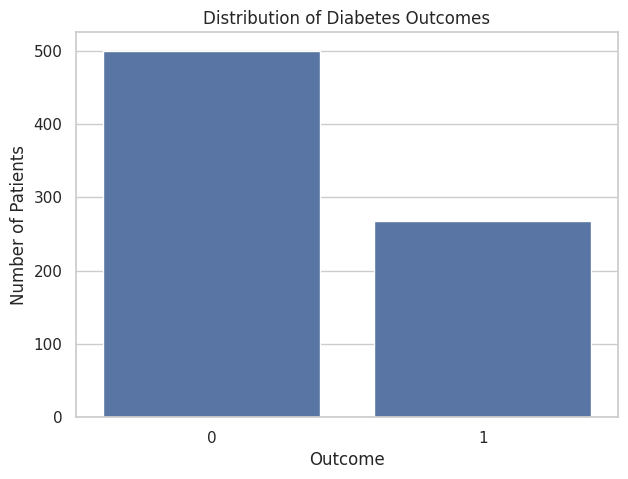

In [10]:
plt.figure(figsize=(7, 5))

sns.countplot(data=df, x="Outcome")

plt.title("Distribution of Diabetes Outcomes")
plt.xlabel("Outcome")
plt.ylabel("Number of Patients")

plt.show()

Handling Invalid Zero Values

Zero values in several medical measurements represent missing or unavailable information rather than real measurements.

I will replace zero values with NaN in the following columns:

Glucose
BloodPressure
SkinThickness
Insulin
BMI

The missing values will then be filled using the median of each column.

The median is used because it is less affected by extreme values than the mean.

In [11]:
columns_with_invalid_zeros = [
    "Glucose",
    "BloodPressure",
    "SkinThickness",
    "Insulin",
    "BMI"
]

df[columns_with_invalid_zeros] = df[columns_with_invalid_zeros].replace(0, np.nan)

df.isnull().sum()

,0
Pregnancies,0
Glucose,5
BloodPressure,35
SkinThickness,227
Insulin,374
BMI,11
DiabetesPedigreeFunction,0
Age,0
Outcome,0


In [12]:
for column in columns_with_invalid_zeros:
    df[column] = df[column].fillna(df[column].median())

print("Missing values after preprocessing:")
print(df.isnull().sum())

Missing values after preprocessing:
Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64


Exploratory Data Analysis

Before training the model, I will explore relationships between the features and diabetes outcomes.

This helps identify patterns in the data and understand which variables may be important for prediction.

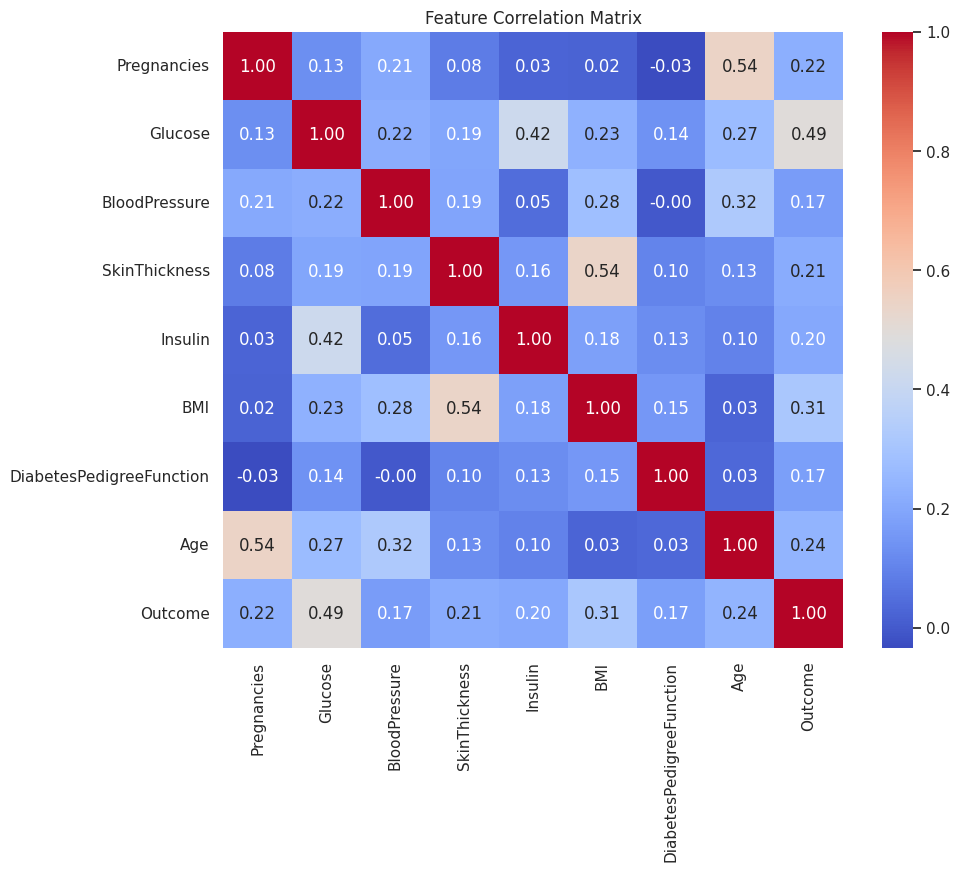

In [13]:
plt.figure(figsize=(10, 8))

correlation_matrix = df.corr()

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Feature Correlation Matrix")

plt.show()

Glucose Distribution

Glucose is expected to be an important feature because diabetes is strongly related to blood glucose levels.

I will compare glucose distributions between patients with and without diabetes.

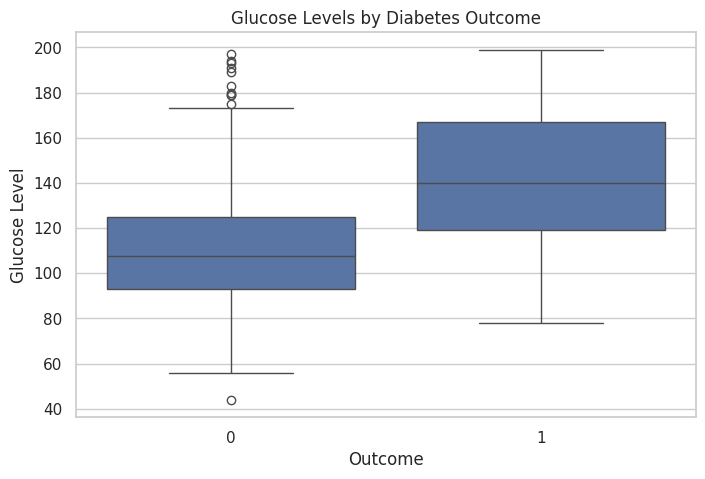

In [14]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="Outcome",
    y="Glucose"
)

plt.title("Glucose Levels by Diabetes Outcome")
plt.xlabel("Outcome")
plt.ylabel("Glucose Level")

plt.show()

BMI Distribution

BMI is another important health-related feature. I will compare the BMI distributions of the two outcome groups.

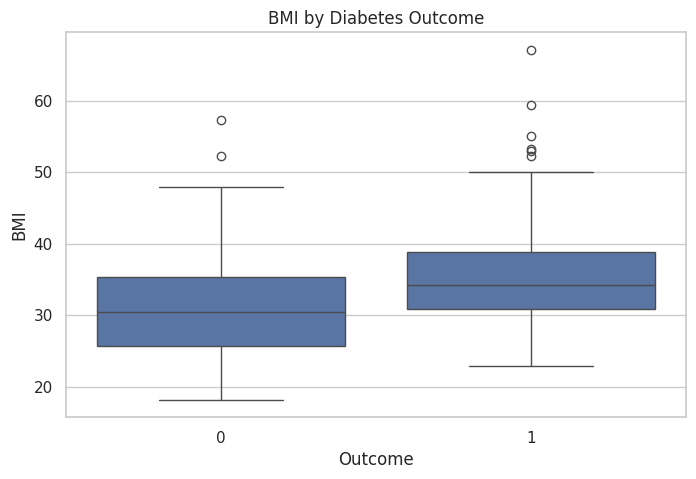

In [15]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="Outcome",
    y="BMI"
)

plt.title("BMI by Diabetes Outcome")
plt.xlabel("Outcome")
plt.ylabel("BMI")

plt.show()

Age Distribution

Age may also have a relationship with diabetes risk. This visualization compares the age distributions of patients with different outcomes.

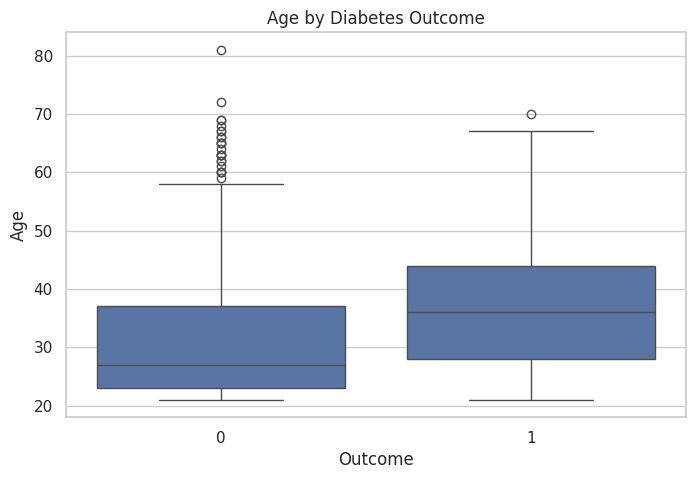

In [16]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="Outcome",
    y="Age"
)

plt.title("Age by Diabetes Outcome")
plt.xlabel("Outcome")
plt.ylabel("Age")

plt.show()

Feature and Target Separation

The Outcome column is the target variable.

The remaining columns will be used as input features for the classification model.

In [17]:
X = df.drop("Outcome", axis=1)
y = df["Outcome"]

print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (768, 8)
Target shape: (768,)


Train-Test Split

The dataset will be divided into two parts:

80% training data
20% testing data

The model will learn patterns from the training data and will then be evaluated on unseen testing data.

random_state=42 is used so that the same split can be reproduced.

stratify=y ensures that the proportion of diabetic and non-diabetic patients remains similar in both datasets.

In [18]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training features shape:", X_train.shape)
print("Testing features shape:", X_test.shape)

print("Training target shape:", y_train.shape)
print("Testing target shape:", y_test.shape)

Training features shape: (614, 8)
Testing features shape: (154, 8)
Training target shape: (614,)
Testing target shape: (154,)


Feature Scaling

The features in this dataset have different numerical ranges.

For example:

Pregnancies contains relatively small values
Insulin can have much larger values
DiabetesPedigreeFunction contains small decimal values

StandardScaler transforms the features so that they have a similar scale.

The scaler is fitted only on the training data to avoid leaking information from the test set into the model.

In [19]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

print("Training data scaled successfully.")
print("Testing data scaled successfully.")

Training data scaled successfully.
Testing data scaled successfully.


Train the Logistic Regression Model

Logistic Regression is a classification algorithm used to predict categories.

In this project, the model predicts two possible outcomes:

0 → No diabetes
1 → Diabetes

The model learns the relationship between the medical features and the diabetes outcome using the training data.

In [20]:
model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

model.fit(X_train_scaled, y_train)

print("Logistic Regression model trained successfully.")

Logistic Regression model trained successfully.


Generate Predictions

After training the model, predictions will be generated for both the training and testing datasets.

The test predictions are especially important because the test data was not used during model training.

In [22]:
y_train_pred = model.predict(X_train_scaled)

y_test_pred = model.predict(X_test_scaled)

print("Predictions generated successfully.")

Predictions generated successfully.


Accuracy

Accuracy measures the percentage of total predictions that were correct.

The formula is:

Accuracy=
Total Predictions
Correct Predictions
	​


For a binary classification problem, accuracy provides a simple overview of model performance.

However, accuracy should not be used alone because it does not show the types of mistakes the model makes.

In [23]:
train_accuracy = accuracy_score(y_train, y_train_pred)

test_accuracy = accuracy_score(y_test, y_test_pred)

print("Training Accuracy:", train_accuracy)
print("Testing Accuracy:", test_accuracy)

Training Accuracy: 0.7964169381107492
Testing Accuracy: 0.7077922077922078


Confusion Matrix

A confusion matrix provides a more detailed view of classification results.

It contains:

True Negative (TN): Correctly predicted no diabetes
False Positive (FP): Predicted diabetes when the actual outcome was no diabetes
False Negative (FN): Predicted no diabetes when the actual outcome was diabetes
True Positive (TP): Correctly predicted diabetes

In [24]:
cm = confusion_matrix(y_test, y_test_pred)

print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[82 18]
 [27 27]]


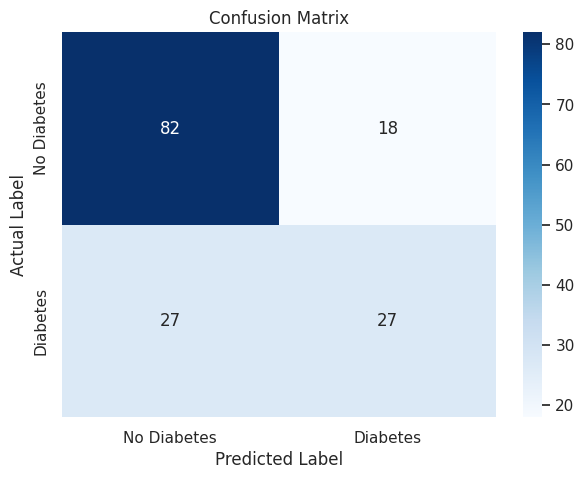

In [25]:
plt.figure(figsize=(7, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["No Diabetes", "Diabetes"],
    yticklabels=["No Diabetes", "Diabetes"]
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")

plt.show()

Classification Report

The classification report provides several important metrics:

Precision

Precision answers:

Of all the patients predicted as diabetic, how many were actually diabetic?

Precision=
TP+FP
TP
	​

Recall

Recall answers:

Of all the patients who actually had diabetes, how many did the model correctly identify?

Recall=
TP+FN
TP
	​

F1-Score

F1-score combines precision and recall.

F1=2×
Precision+Recall
Precision×Recall
	​


In [26]:
print("Classification Report:")
print(classification_report(y_test, y_test_pred))

Classification Report:
              precision    recall  f1-score   support

           0       0.75      0.82      0.78       100
           1       0.60      0.50      0.55        54

    accuracy                           0.71       154
   macro avg       0.68      0.66      0.67       154
weighted avg       0.70      0.71      0.70       154



Individual Classification Metrics

The individual metrics are calculated separately to make the model's performance easier to analyze.

In [27]:
precision = precision_score(y_test, y_test_pred)

recall = recall_score(y_test, y_test_pred)

f1 = f1_score(y_test, y_test_pred)

print("Precision:", precision)
print("Recall:", recall)
print("F1-Score:", f1)

Precision: 0.6
Recall: 0.5
F1-Score: 0.5454545454545454


Mean Absolute Error (MAE)

Although MAE is primarily used for regression problems, it can also be calculated for binary classification predictions represented as 0 and 1.

The formula is:

MAE = (1/n) * sum(|Actual - Predicted|)


For binary predictions:

A correct prediction produces an error of 0
An incorrect prediction produces an error of 1

Therefore, MAE represents the proportion of incorrect predictions.

In [28]:
mae = mean_absolute_error(y_test, y_test_pred)

print("Mean Absolute Error (MAE):", mae)

Mean Absolute Error (MAE): 0.2922077922077922


Mean Squared Error (MSE)

MSE calculates the average squared difference between actual and predicted values.

The formula is:

MSE = (1/n) * Σ(Actual - Predicted)²

For binary classification, incorrect predictions create an error of 1, while correct predictions create an error of 0.

In [29]:
mse = mean_squared_error(y_test, y_test_pred)

print("Mean Squared Error (MSE):", mse)

Mean Squared Error (MSE): 0.2922077922077922


Root Mean Squared Error (RMSE)

RMSE is the square root of MSE.

The formula is:
RMSE = sqrt( (1/n) * sum( (Actual - Predicted)^2 ) )


RMSE is useful because it brings the error back to the original scale of the target values.

In [30]:
rmse = np.sqrt(mse)

print("Root Mean Squared Error (RMSE):", rmse)

Root Mean Squared Error (RMSE): 0.5405624776173353


R² Score

R², or the coefficient of determination, measures how much variation in the target variable is explained by the predictions.

The formula is:

R^2 = 1 - (Sum of Squared Residuals / Total Sum of Squares)
	​


For classification problems, R² is not the primary evaluation metric. Classification metrics such as accuracy, precision, recall, F1-score, and ROC-AUC are generally more appropriate.

However, calculating R² here helps demonstrate how this metric behaves when predictions are represented as binary values.

In [31]:
r2 = r2_score(y_test, y_test_pred)

print("R² Score:", r2)

R² Score: -0.28333333333333344


Complete Model Evaluation

The following cell summarizes the main evaluation metrics in one place.

In [32]:
evaluation_results = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1-Score",
        "MAE",
        "MSE",
        "RMSE",
        "R² Score"
    ],
    "Value": [
        test_accuracy,
        precision,
        recall,
        f1,
        mae,
        mse,
        rmse,
        r2
    ]
})

evaluation_results

,Metric,Value
0,Accuracy,0.707792
1,Precision,0.600000
2,Recall,0.500000
3,F1-Score,0.545455
4,MAE,0.292208
5,MSE,0.292208
6,RMSE,0.540562
7,R² Score,-0.283333


Training vs Testing Performance

To check whether the model is overfitting, I will compare its performance on the training and testing datasets.

If the training performance is much higher than the testing performance, the model may be overfitting.

If both scores are reasonably close, the model is likely generalizing better to unseen data.

In [33]:
performance_comparison = pd.DataFrame({
    "Dataset": [
        "Training Data",
        "Testing Data"
    ],
    "Accuracy": [
        train_accuracy,
        test_accuracy
    ]
})

performance_comparison

,Dataset,Accuracy
0,Training Data,0.796417
1,Testing Data,0.707792


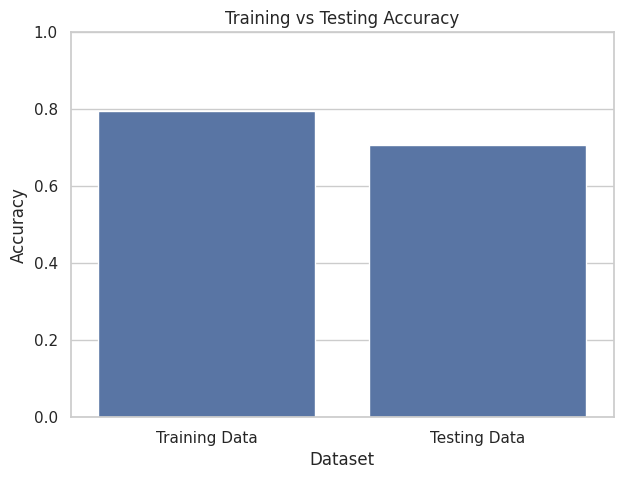

In [34]:
plt.figure(figsize=(7, 5))

sns.barplot(
    data=performance_comparison,
    x="Dataset",
    y="Accuracy"
)

plt.title("Training vs Testing Accuracy")
plt.ylim(0, 1)

plt.show()

Model Coefficients

Logistic Regression assigns a coefficient to each feature.

A positive coefficient means that increasing the feature generally increases the model's tendency toward predicting diabetes.

A negative coefficient means that increasing the feature generally decreases the model's tendency toward predicting diabetes.

The magnitude of the coefficient indicates how strongly the feature contributes to the model after scaling.

In [35]:
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_[0]
})

feature_importance["Absolute Coefficient"] = (
    feature_importance["Coefficient"].abs()
)

feature_importance = feature_importance.sort_values(
    by="Absolute Coefficient",
    ascending=False
)

feature_importance

,Feature,Coefficient,Absolute Coefficient
1,Glucose,1.182511,1.182511
5,BMI,0.688735,0.688735
0,Pregnancies,0.377502,0.377502
6,DiabetesPedigreeFunction,0.233386,0.233386
7,Age,0.147798,0.147798
4,Insulin,-0.066157,0.066157
2,BloodPressure,-0.044066,0.044066
3,SkinThickness,0.028225,0.028225


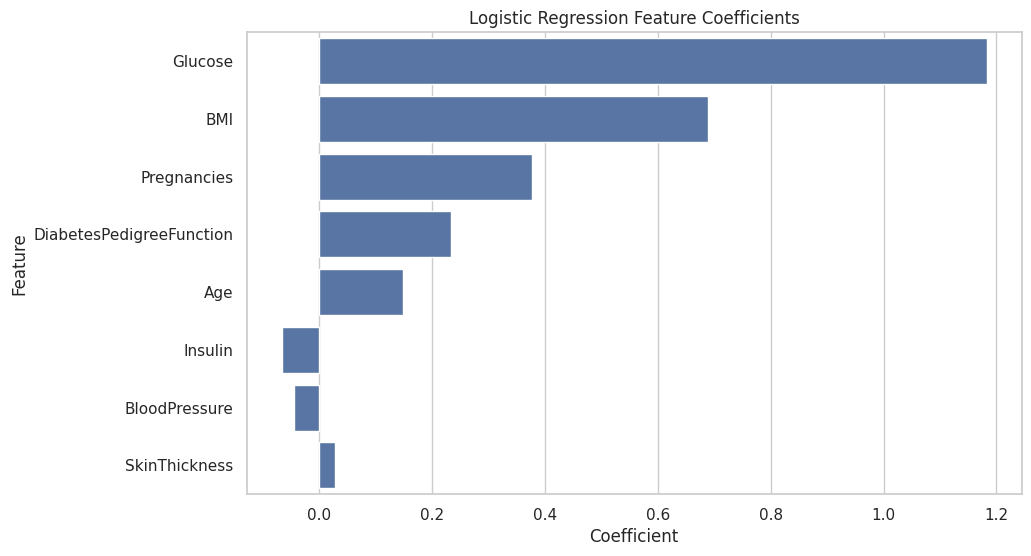

In [36]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=feature_importance,
    x="Coefficient",
    y="Feature"
)

plt.title("Logistic Regression Feature Coefficients")

plt.show()

Prediction Probability

The model can also provide probabilities instead of only predicting 0 or 1.

For each patient, the model calculates the probability of belonging to each class.

The probability for class 1 represents the model's estimated probability that the patient has diabetes.

In [37]:
y_test_probability = model.predict_proba(X_test_scaled)[:, 1]

prediction_results = pd.DataFrame({
    "Actual Outcome": y_test.values,
    "Predicted Outcome": y_test_pred,
    "Diabetes Probability": y_test_probability
})

prediction_results.head(10)

,Actual Outcome,Predicted Outcome,Diabetes Probability
0,0,1,0.609711
1,0,0,0.118356
2,0,0,0.293463
3,1,0,0.250837
4,0,0,0.033207
5,0,0,0.168524
6,1,0,0.488164
7,1,1,0.923675
8,0,0,0.081434
9,0,1,0.838590


Example Predictions

The following table shows actual outcomes, predicted outcomes, and the probability assigned by the model.

This makes the model's predictions easier to inspect.

In [38]:
prediction_results.head(20)

,Actual Outcome,Predicted Outcome,Diabetes Probability
0,0,1,0.609711
1,0,0,0.118356
2,0,0,0.293463
3,1,0,0.250837
4,0,0,0.033207
5,0,0,0.168524
6,1,0,0.488164
7,1,1,0.923675
8,0,0,0.081434
9,0,1,0.838590


Final Conclusion

The diabetes prediction model was successfully developed using Logistic Regression.

The complete machine learning workflow included:

Dataset loading using KaggleHub
Preliminary Data Analysis
Data inspection
Handling invalid zero values
Median-based missing value treatment
Exploratory data visualization
Feature and target separation
Train-test splitting
Feature scaling
Logistic Regression training
Generating predictions
Accuracy evaluation
Confusion matrix analysis
Precision, recall, and F1-score evaluation
MAE, MSE, RMSE, and R² calculation
Training and testing performance comparison
Feature coefficient analysis

The model's performance should primarily be judged using classification metrics such as accuracy, precision, recall, and F1-score. In a medical prediction problem, recall can be particularly important because failing to identify a patient who actually has diabetes may be a serious error.